# **SIEĆ NEURONOWA DO MAGISTERKI**
# [Github](https://github.com/propa-zaman/Movie-Recommendation-System-using-GNN/blob/main/README.md#requirements)
# [Dane](https://grouplens.org/datasets/movielens/)


Instaluję wymagane biblioteki

In [6]:
# Instalacja PyTorch
!pip install torch torchvision torchaudio

# Sprawdzenie zainstalowanej wersji PyTorch
import torch
torch_version = torch.__version__
print(f'Wersja PyTorch: {torch_version}')

# Instalacja zależności dla PyTorch Geometric
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch_version}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{torch_version}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{torch_version}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git

# Instalacja dodatkowych bibliotek
!pip install pandas numpy scikit-learn matplotlib




Wersja PyTorch: 2.5.1+cu121
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 77.1 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 53.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.6 MB/s eta 0:00:00
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-3g92s1le
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-3g92s1le
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit ef028547ff4459f6e98fe429d1564bd1d513fc31
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch-geometric: filename=torch_geometric-2.

Importuje biblioteki i ustawienia

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random



**Dokumentacja i ziarno losowe**
Aby zapewnić reprodukowalność wyników, upewnij się, że ustawiłeś ziarno losowe na początku notebooka.

In [8]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

Optymalizacja Hiperparametrów
Zastosowanie hiperparametrów ułatwia modyfikacje w jednym miejscu i wpływa na cały kod.

In [9]:
# Hiperparametry
embedding_dim = 64  # Wymiar osadzeń
learning_rate = 0.005  # Współczynnik uczenia
num_epochs = 30  # Liczba epok
weight_decay = 1e-5  # Regularyzacja L2
dropout_rate = 0.5  # Dropout


Pobieranie i Przygotowanie Danych
Pobierz dane z MovieLens i przygotuj je do użycia w modelu.

In [10]:
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip ml-100k.zip

# Wczytywanie danych
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
data = pd.read_csv('ml-100k/u.data', sep='\t', names=column_names)

# Usuwanie kolumny 'timestamp'
data = data.drop('timestamp', axis=1)

# Mapowanie identyfikatorów użytkowników i filmów
user_map = {id: idx for idx, id in enumerate(data['user_id'].unique())}
item_map = {id: idx for idx, id in enumerate(data['item_id'].unique())}
data['user_id'] = data['user_id'].map(user_map)
data['item_id'] = data['item_id'].map(item_map)

# Podział na zbiory treningowy i testowy
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Wyświetlenie rozmiarów zbiorów
print(f"Liczba próbek treningowych: {len(train_data)}")
print(f"Liczba próbek testowych: {len(test_data)}")


# Wyświetlenie kilku wierszy po mapowaniu
print("Dane po mapowaniu:")
print(data.head())



--2025-01-12 21:07:17--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.65.152
Connecting to files.grouplens.org (files.grouplens.org)|128.101.65.152|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  22.2MB/s    in 0.2s    

2025-01-12 21:07:18 (22.2 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.ba

Rozkład ocen

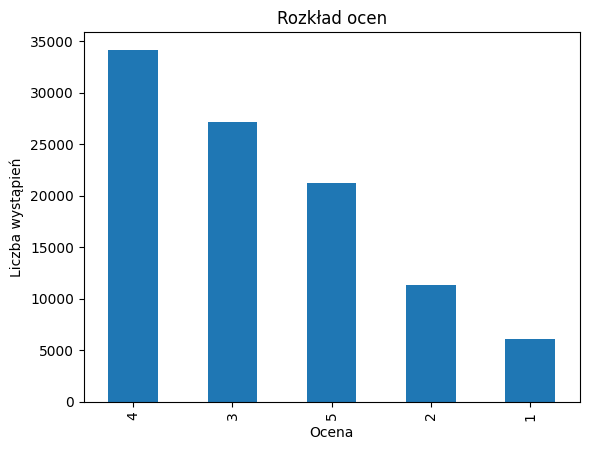

In [11]:
data['rating'].value_counts().plot(kind='bar')
plt.title('Rozkład ocen')
plt.xlabel('Ocena')
plt.ylabel('Liczba wystąpień')
plt.show()


Tworzenie Grafu dla PyTorch Geometric
Przygotuj dane w formacie wymaganym przez PyTorch Geometric.

In [14]:
labels = torch.tensor(train_data['rating'].values, dtype=torch.float)

# Jeśli edge_index zawiera krawędzie zwrotne
labels = torch.cat([labels, labels], dim=0)  # Podwojenie tylko raz



In [15]:
# Tworzenie edge_index dla zbioru treningowego
edge_index = torch.tensor(
    np.array([
        train_data['user_id'].values,
        train_data['item_id'].values + len(user_map)
    ]),
    dtype=torch.long
)


# Wyświetlenie informacji o grafie
print(f"Kształt edge_index: {edge_index.shape}")
print(f"Kształt labels: {labels.shape}")


Kształt edge_index: torch.Size([2, 80000])
Kształt labels: torch.Size([160000])


Definiuje model grafowej sieci neuronowej z wykorzystaniem warstw GCN

In [18]:
class RecommenderGNN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim, dropout_rate):
        super(RecommenderGNN, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.gcn = GCNConv(embedding_dim, embedding_dim)
        self.fc = nn.Linear(embedding_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, user_indices, item_indices, edge_index):
        user_emb = self.user_embedding(user_indices)
        item_emb = self.item_embedding(item_indices)
        x = torch.cat([user_emb, item_emb], dim=0)
        x = self.gcn(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x



In [19]:
model = RecommenderGNN(num_users, num_items, embedding_dim, dropout_rate)


NameError: name 'num_users' is not defined

Trenowanie Modelu
Przeprowadź proces trenowania modelu.

In [ ]:
# Inicjalizacja modelu
num_users = len(user_map)
num_items = len(item_map)
embedding_dim = 64
model = RecommenderGNN(num_users, num_items, embedding_dim, dropout_rate)

# Optymalizator i funkcja straty
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
weights = torch.tensor([1.0, 2.0])  # Dostosuj wagi do danych
criterion = nn.MSELoss(reduction='mean')

# Trenowanie modelu
num_epochs = 20
train_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Przygotowanie indeksów użytkowników i filmów
    user_indices = torch.tensor(train_data['user_id'].values, dtype=torch.long)
    item_indices = torch.tensor(train_data['item_id'].values, dtype=torch.long)

    # Przewidywanie ocen
    predictions = model(user_indices, item_indices, edge_index).squeeze()

    # Sprawdzenie wymiarów
    print(f"Rozmiar predictions: {predictions.size()}")
    print(f"Rozmiar labels: {labels.size()}")

    # Obliczanie straty
    loss = criterion(predictions, labels)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}')

# Wykres strat treningowych
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss over Epochs')
plt.show()



Tworzenie edge_index dla zbioru testowego


In [ ]:
# Tworzenie edge_index dla zbioru testowego
test_edge_index = torch.tensor(
    np.array([
        test_data['user_id'].values,
        test_data['item_id'].values + len(user_map)
    ]),
    dtype=torch.long
)

Ewaluacja Modelu
Oceń model na zbiorze testowym.

In [ ]:
# Etykiety dla zbioru testowego
test_labels = torch.tensor(test_data['rating'].values, dtype=torch.float)

# Podwajanie test_labels dla krawędzi zwrotnych
test_labels = torch.cat([test_labels, test_labels], dim=0)

# Ewaluacja modelu
model.eval()
with torch.no_grad():
    user_indices = torch.tensor(test_data['user_id'].values, dtype=torch.long)
    item_indices = torch.tensor(test_data['item_id'].values, dtype=torch.long)
    predictions = model(user_indices, item_indices, test_edge_index).squeeze()
    test_loss = criterion(predictions, test_labels)
    print(f'Test Loss: {test_loss.item()}')



In [ ]:
from sklearn.metrics import mean_absolute_error

# Ewaluacja
model.eval()
with torch.no_grad():
    predictions = predictions.cpu().numpy()
    test_labels = test_labels.cpu().numpy()
    rmse = np.sqrt(np.mean((predictions - test_labels)**2))

print(f"Test RMSE: {rmse}")


Generowanie Rekomendacji
Stwórz funkcję do generowania rekomendacji dla użytkowników.

In [ ]:
def recommend_movies(user_id, num_recommendations=5):
    model.eval()
    user_idx = torch.tensor([user_map[user_id]] * num_items, dtype=torch.long)
    item_indices = torch.tensor(list(item_map.values()), dtype=torch.long)
    with torch.no_grad():
        scores = model(user_idx, item_indices, edge_index).squeeze()
    top_items = torch.topk(scores, num_recommendations).indices
    recommended_items = [list(item_map.keys())[i] for i in top_items]
    return recommended_items

# Przykład rekomendacji dla użytkownika o ID 1
recommendations = recommend_movies(1)
print(f'Recommended items for user 1: {recommendations}')


** Wizualizacja wyników**
Dodanie więcej wykresów, aby lepiej zrozumieć wyniki.

In [ ]:
# Wykres strat treningowych
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()


# Wykres porównania predykcji i rzeczywistych etykiet
plt.figure()
plt.scatter(test_labels[:100], predictions[:100], alpha=0.5)
plt.plot([0, 5], [0, 5], '--r', label='Ideal Line')
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Predicted vs True Ratings')
plt.legend()
plt.show()



plt.figure(figsize=(10, 6))
plt.scatter(test_labels, predictions, alpha=0.5)
plt.plot([0, 5], [0, 5], '--r')
plt.xlabel('Rzeczywiste oceny')
plt.ylabel('Przewidywane oceny')
plt.title('Porównanie przewidywanych i rzeczywistych ocen')
plt.show()



In [ ]:
print(f"Rozmiar predictions: {predictions.size()}")
print(f"Rozmiar labels: {labels.size()}")